Install Packages and Import Libraries

In [ ]:
# Install dependencies
%pip install -r ../requirements.txt

In [1]:
# Import libraries and add preprocessing helpers to path.
import torch
import subprocess
import sys
import os
import json
import cv2
from pathlib import Path
import shutil
import numpy as np
from PIL import Image
from dotenv import load_dotenv
from imagededup.methods import CNN
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import pandas as pd
import random

sys.path.insert(0, str(Path('../src/local/preprocessing').resolve()))
from helpers import get_busi, remove_duplicates, has_edge_touching_lesion, combine_busi_masks
from caliper_cleaning import preprocess_image

Check GPU Availability

In [2]:
# Verify CUDA for CNN deduplication and EasyOCR.
print(f'cuda: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'gpu: {torch.cuda.get_device_name(0)}')

cuda: True
gpu: NVIDIA GeForce RTX 3080


 Download the BUSI Dataset

In [3]:
# Download BUSI dataset.
busi_raw_path = get_busi()
print(f'dataset downloaded: {busi_raw_path}')

dataset downloaded: C:\Users\User\busi-vlm-localisation\dataset\raw\Dataset_BUSI_with_GT


Configure Preprocessing Parameters and Output Paths

In [4]:
# Settings.
train_ratio, validation_ratio, test_ratio = 0.70, 0.15, 0.15
duplication_threshold = 0.96
seed = 42

# Paths.
raw = busi_raw_path
step1 = Path('../dataset/processing/step1_masks')
step2 = Path('../dataset/processing/step2_no_edge')
step3 = Path('../dataset/processing/step3_no_dup')
clean = Path('../dataset/clean')
split = Path('../dataset/split')

# Track final dataset only.
index = []

Combine Multi-Lesion Masks

In [5]:
# Merge multiple BUSI lesion masks into one mask per image so each ultrasound has a consistent segmentation target.
for category in ['benign', 'malignant', 'normal']:
    stats = combine_busi_masks(raw / category, step1 / category)
    print(f'{category}: {stats["multi_lesion"]} multi, {stats["single_lesion"]} single')

benign: 16 multi, 421 single
malignant: 1 multi, 209 single
normal: 0 multi, 133 single


Remove Edge-Touching Lesions

In [6]:
# Filter images where the lesion touches the image border to avoid partial lesions.
for category in ['benign', 'malignant', 'normal']:
    (step2 / category).mkdir(parents=True, exist_ok=True)
    
    masks = list((step1 / category).glob('*_mask.png'))
    kept = removed = 0
    
    for mask_path in masks:
        if has_edge_touching_lesion(mask_path):
            removed += 1
            continue
        
        shutil.copy2(mask_path, step2 / category / mask_path.name)
        image_name = mask_path.name.replace('_mask.png', '.png')
        shutil.copy2(raw / category / image_name, step2 / category / image_name)
        kept += 1
    
    print(f'{category}: kept {kept}, removed {removed} edge-touching')

benign: kept 431, removed 6 edge-touching
malignant: kept 204, removed 6 edge-touching
normal: kept 133, removed 0 edge-touching


Remove Near-Duplicate Images

In [7]:
# Use CNN feature similarity to remove duplicated scans as well as reduce train and test leakage (especially for BUSSAM training).
duplication_stats = remove_duplicates(step2, step3, threshold = duplication_threshold)

for category, stats in duplication_stats.items():
    print(f"{category}: kept {stats['kept']} - removed {stats['removed']} duplicates")

2026-05-29 23:30:52,666: INFO Device set to cuda ..
2026-05-29 23:30:52,700: INFO Initialized: mobilenet_v3_small for feature extraction ..
2026-05-29 23:30:52,728: INFO Start: Image encoding generation
2026-05-29 23:31:02,006: INFO End: Image encoding generation
2026-05-29 23:31:02,039: INFO Start: Calculating cosine similarities...
2026-05-29 23:31:02,044: INFO End: Calculating cosine similarities.
2026-05-29 23:31:02,599: INFO Start: Image encoding generation
2026-05-29 23:31:06,848: INFO End: Image encoding generation
2026-05-29 23:31:06,867: INFO Start: Calculating cosine similarities...
2026-05-29 23:31:06,870: INFO End: Calculating cosine similarities.
2026-05-29 23:31:07,186: INFO Start: Image encoding generation
2026-05-29 23:31:10,227: INFO End: Image encoding generation
2026-05-29 23:31:10,236: INFO Start: Calculating cosine similarities...
2026-05-29 23:31:10,238: INFO End: Calculating cosine similarities.


benign: kept 340 - removed 91 duplicates
malignant: kept 190 - removed 14 duplicates
normal: kept 95 - removed 38 duplicates


Detect and Inpaint Calipers and Text Overlays

In [8]:
# We noticed that many ultrasound datasets retain measurement calipers, text labels, and overlay lines so we remove these artefacts. 
# This helps the VLMs learn lesion features and texture rather than shortcut annotation cues.
for category in ['benign', 'malignant', 'normal']:
    (clean / category).mkdir(parents=True, exist_ok=True)

    images = sorted([f for f in (step3 / category).iterdir() if f.suffix == '.png' and '_mask' not in f.name])

    caliper_count = 0
    fallback_count = 0
    ocr_region_count = 0

    progress = tqdm(images, desc=category, unit='img', dynamic_ncols=True, leave=True)

    for image_path in progress:
        image = cv2.imread(str(image_path))

        if image is None:
            progress.set_postfix(status='read error', refresh=True)
            continue

        cleaned, detections = preprocess_image(image)
        cv2.imwrite(str(clean / category / image_path.name), cleaned)

        number_calipers = len(detections['caliper_boxes_raw'])
        number_dotted = len(detections['dotted_lines'])
        number_traced = len(detections.get('traced_lines', []))
        number_ocr = detections['ocr_regions']

        if number_calipers > 0:
            caliper_count += 1

        if detections['used_fallback']:
            fallback_count += 1

        ocr_region_count += number_ocr

        progress.set_postfix(
            current=f'{number_calipers}cal/{number_dotted + number_traced}line/{number_ocr}ocr',
            fallback=fallback_count,
            with_calipers=caliper_count,
            refresh=True
        )

        mask_path = image_path.parent / f"{image_path.stem}_mask.png"

        if mask_path.exists():
            shutil.copy2(mask_path, clean / category / mask_path.name)

        is_multi_lesion = len(
            list((raw / category).glob(f"{image_path.stem}_mask*.png"))
        ) > 1

        height, width = image.shape[:2]
        has_mask = mask_path.exists()
        mask_area_ratio = 0.0

        if has_mask:
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            mask_area_ratio = np.count_nonzero(mask) / (height * width)

        if not has_mask:
            continue

        index.append({'image_id': image_path.stem, 'class_label': category, 'width': width, 'height': height, 'has_mask': has_mask, 'mask_area_ratio': mask_area_ratio, 'multi_lesion': is_multi_lesion})

    progress.close()

    print(
        f'{category}: {len(images)} cleaned, '
        f'{caliper_count} with calipers, '
        f'{fallback_count} fallback detections, '
        f'{ocr_region_count} OCR regions'
    )

benign:   0%|          | 0/340 [00:00<?, ?img/s]

benign: 340 cleaned, 151 with calipers, 110 fallback detections, 102 OCR regions


malignant:   0%|          | 0/190 [00:00<?, ?img/s]

malignant: 190 cleaned, 65 with calipers, 53 fallback detections, 73 OCR regions


normal:   0%|          | 0/95 [00:00<?, ?img/s]

normal: 95 cleaned, 18 with calipers, 17 fallback detections, 13 OCR regions


Show Caliper Detection and Inpainting

benign (112): 4 calipers, 2 dotted, 0 traced
benign (122): 0 calipers, 0 dotted, 0 traced
benign (170): 0 calipers, 0 dotted, 0 traced
benign (207): 2 calipers, 1 dotted, 0 traced
benign (213): 2 calipers, 0 dotted, 1 traced
benign (227): 5 calipers, 2 dotted, 0 traced


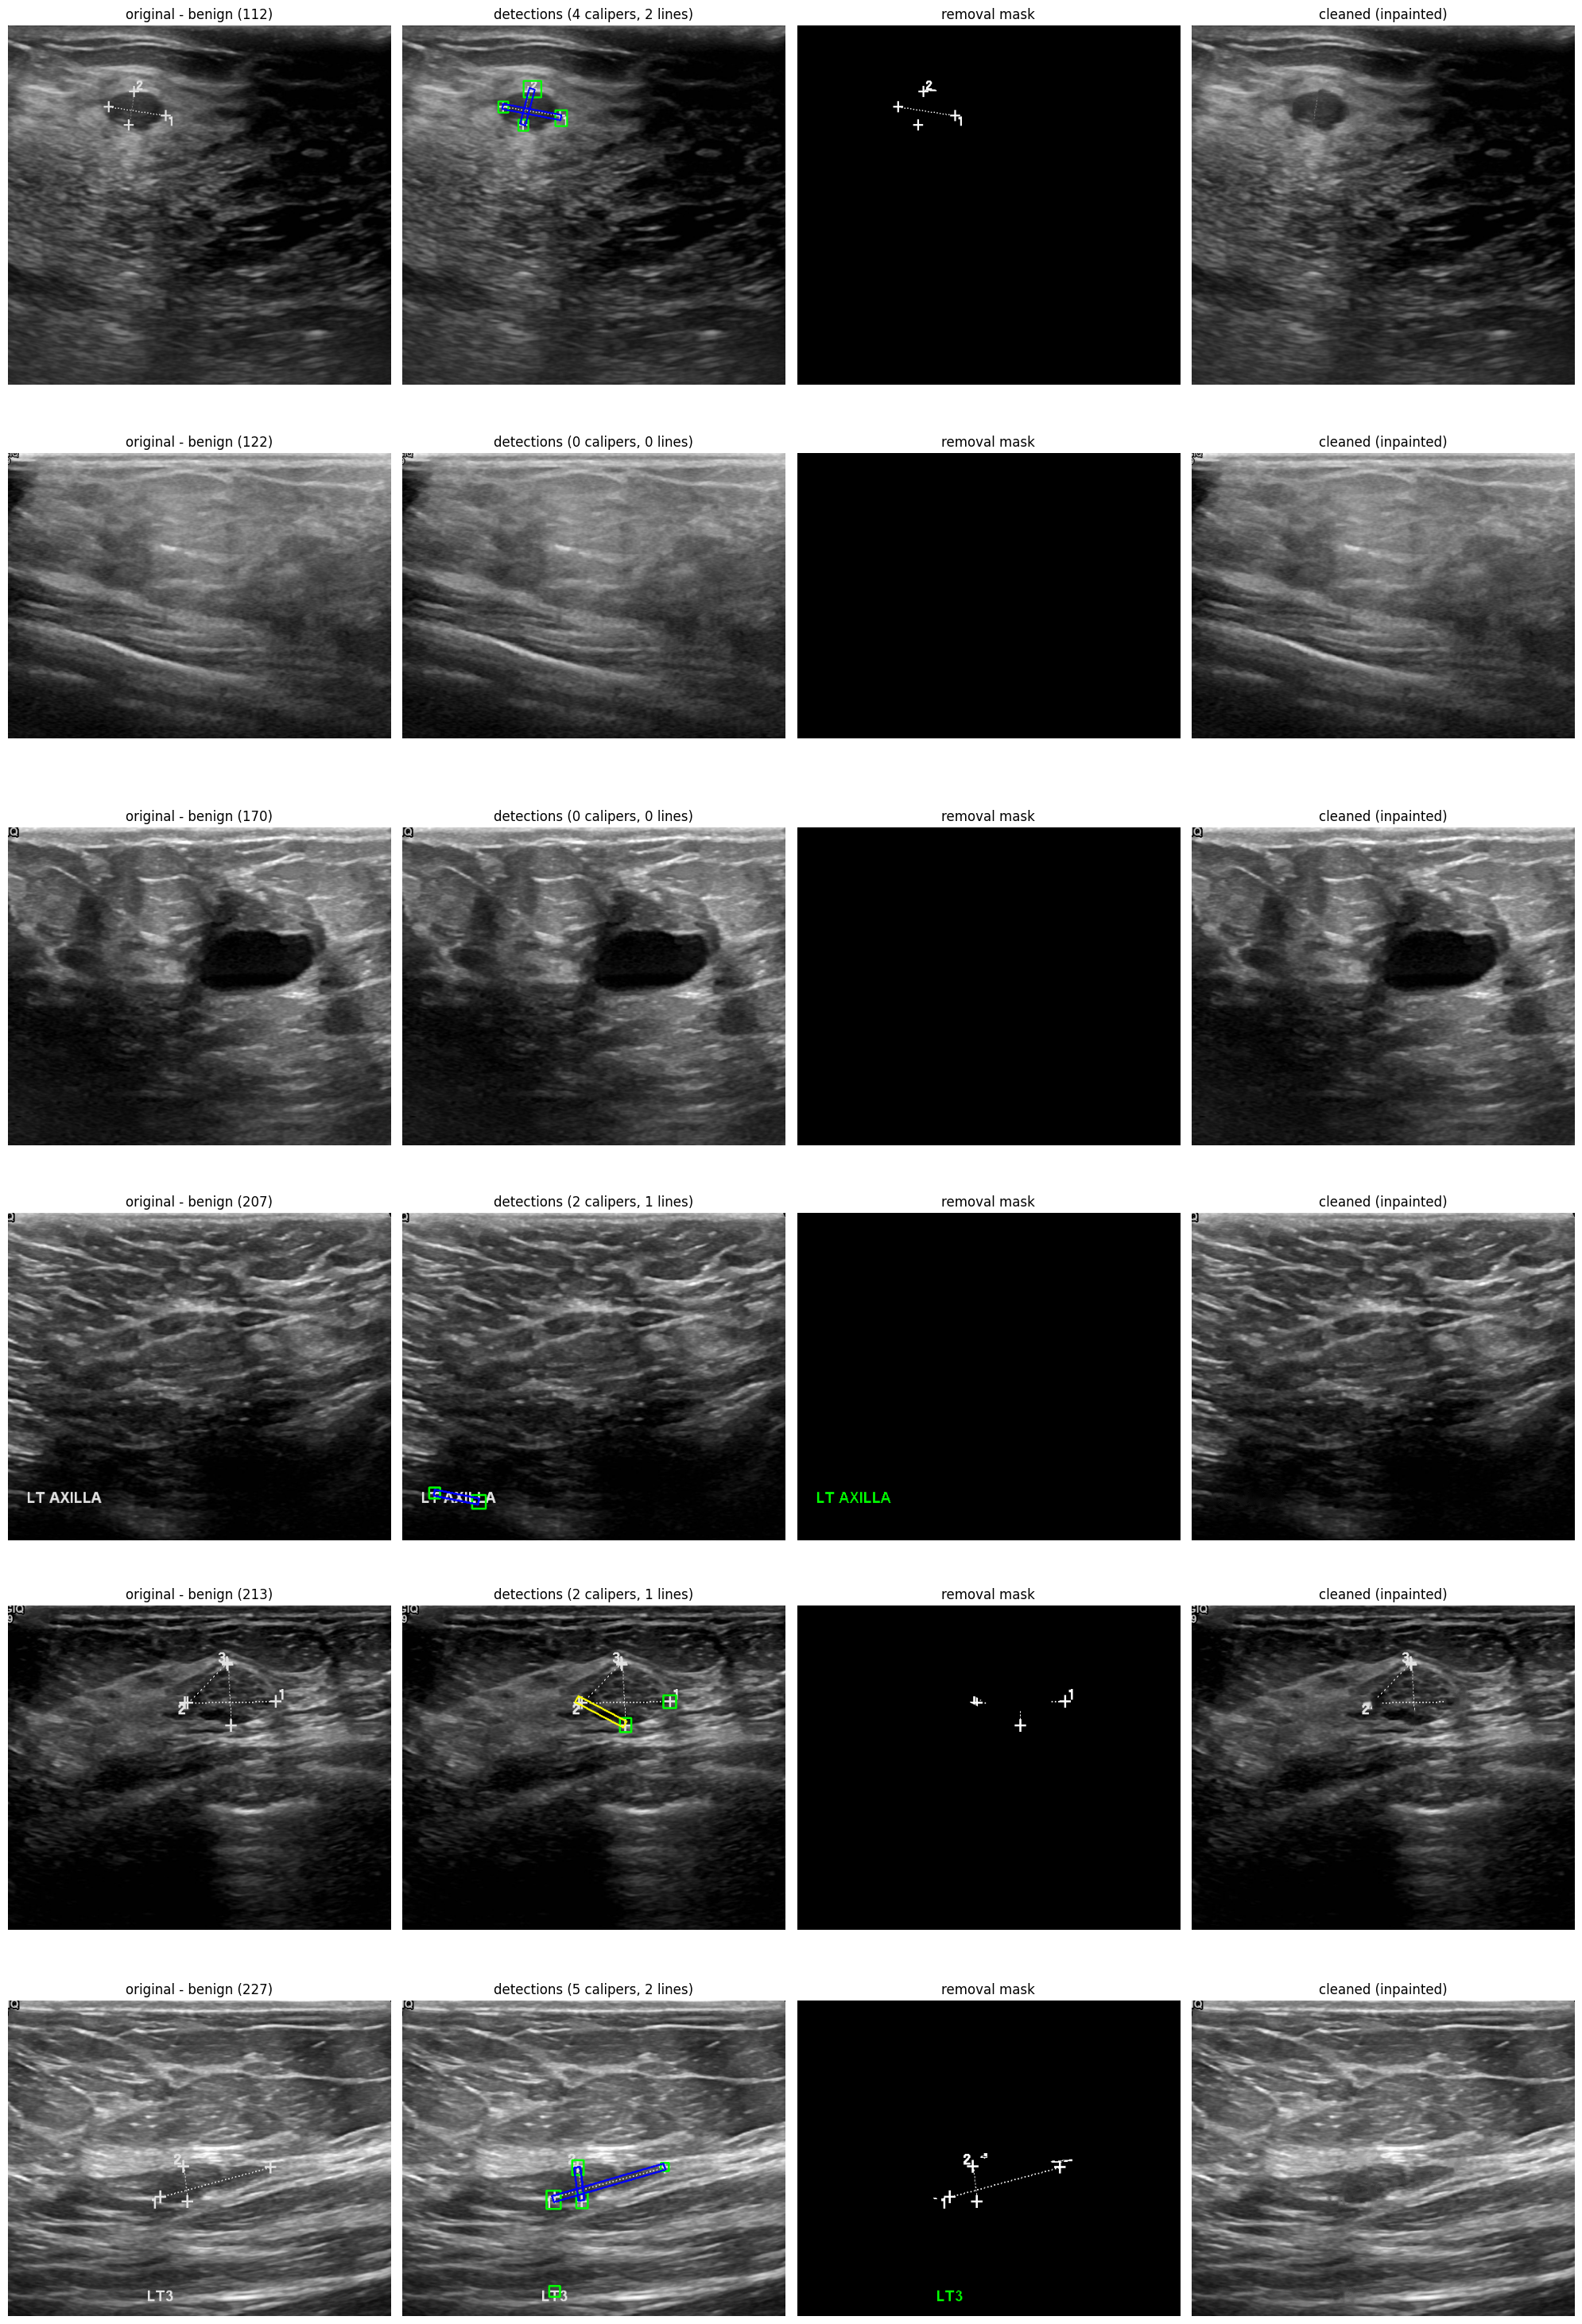

In [9]:
# Visualize caliper cleaning: original | detections | mask | cleaned.
samples = [record for record in index if random.random() < 0.02][:6]

if samples:
    number_samples = len(samples)
    fig, axes = plt.subplots(number_samples, 4, figsize=(20, 5 * number_samples))
    if number_samples == 1:
        axes = axes[None, :]
    
    for row, record in enumerate(samples):
        category = record['class_label']
        image_id = record['image_id']
        
        original = cv2.imread(str(step3 / category / f"{image_id}.png"))
        cleaned = cv2.imread(str(clean / category / f"{image_id}.png"))
        _, detections = preprocess_image(original)
        
        visualization = original.copy()
        for x1, y1, x2, y2 in detections['caliper_boxes_raw']:
            cv2.rectangle(visualization, (x1, y1), (x2, y2), (0, 255, 0), 2)
        for line in detections['dotted_lines']:
            cv2.polylines(visualization, [line['polygon']], True, (255, 0, 0), 2)
        for line in detections.get('traced_lines', []):
            cv2.polylines(visualization, [line['polygon']], True, (0, 255, 255), 2)
        
        # Build 3-channel mask visualization.
        mask = detections['mask']
        mask_visualization = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
        mask_visualization[detections['grey_mask'] > 0] = (255, 255, 255)  # white: calipers/lines.
        mask_visualization[detections['colour_mask'] > 0] = (0, 0, 255)    # red: coloured overlays.
        mask_visualization[detections['text_mask'] > 0] = (0, 255, 0)      # green: ocr text.
        
        number_calipers = len(detections['caliper_boxes_raw'])
        number_dotted = len(detections['dotted_lines'])
        number_traced = len(detections.get('traced_lines', []))
        
        print(f"{image_id}: {number_calipers} calipers, {number_dotted} dotted, {number_traced} traced")
        
        axes[row, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(f'original - {image_id}')
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB))
        axes[row, 1].set_title(f'detections ({number_calipers} calipers, {number_dotted + number_traced} lines)')
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow(cv2.cvtColor(mask_visualization, cv2.COLOR_BGR2RGB))
        axes[row, 2].set_title('removal mask')
        axes[row, 2].axis('off')
        
        axes[row, 3].imshow(cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB))
        axes[row, 3].set_title('cleaned (inpainted)')
        axes[row, 3].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print('no samples selected for visualization')

Create Stratified Splits and  Save Final BUSI Metadata Index

In [10]:
# Stratified train/val/test split.
dataframe = pd.DataFrame(index)

print(f'\ntotal images: {len(dataframe)}')
print(f'by category: {dataframe.groupby("class_label").size().to_dict()}')
print(f'multi-lesion: {dataframe["multi_lesion"].sum()}')
print(f'\nsplit ratios: train={train_ratio}, validation={validation_ratio}, test={test_ratio}\n')

for category in ['benign', 'malignant', 'normal']:
    category_dataframe = dataframe[dataframe['class_label'] == category].copy()
    
    if len(category_dataframe) == 0:
        continue
    
    train_dataframe, temp_dataframe = train_test_split(
        category_dataframe,
        test_size=validation_ratio + test_ratio,
        random_state=seed,
        shuffle=True
    )
    
    validation_dataframe, test_dataframe = train_test_split(
        temp_dataframe,
        test_size=test_ratio / (validation_ratio + test_ratio),
        random_state=seed,
        shuffle=True
    )
    
    for split_name, split_dataframe in [('train', train_dataframe), ('val', validation_dataframe), ('test', test_dataframe)]:
        destination = split / split_name / category
        destination.mkdir(parents=True, exist_ok=True)
        
        for row_index, row in split_dataframe.iterrows():
            image_file = clean / category / f"{row['image_id']}.png"
            mask_file = clean / category / f"{row['image_id']}_mask.png"
            
            destination_image = destination / image_file.name
            destination_mask = destination / mask_file.name
            
            shutil.copy2(image_file, destination_image)
            
            if mask_file.exists():
                shutil.copy2(mask_file, destination_mask)
                dataframe.loc[row_index, 'mask_path'] = f'dataset/split/{split_name}/{category}/{destination_mask.name}'
            else:
                dataframe.loc[row_index, 'mask_path'] = None
            
            dataframe.loc[row_index, 'split'] = split_name
            dataframe.loc[row_index, 'image_path'] = f'dataset/split/{split_name}/{category}/{destination_image.name}'
    
    print(f'{category}: train={len(train_dataframe)}, validation={len(validation_dataframe)}, test={len(test_dataframe)}')

output = Path('../dataset/busi_index.csv')
dataframe[['image_id', 'class_label', 'split', 'image_path', 'mask_path', 'has_mask', 
    'width', 'height', 'mask_area_ratio', 'multi_lesion']].to_csv(output, index=False)

print(f'\nsaved: {output} ({len(dataframe)} images)')


total images: 625
by category: {'benign': 340, 'malignant': 190, 'normal': 95}
multi-lesion: 11

split ratios: train=0.7, validation=0.15, test=0.15

benign: train=238, validation=51, test=51
malignant: train=133, validation=28, test=29
normal: train=66, validation=14, test=15

saved: ..\dataset\busi_index.csv (625 images)
